## What is happening in the next code?
This code prepares the data for the final model. It sets the project paths, creates a `final_model` output folder, and loads the best BCE continuation checkpoint (the model selected as the winner). From this checkpoint it reads the class mapping and builds the sorted list of class names.
It loads the train, validation, and test CSV files, then joins train and validation into one bigger training set (`combined_df`), so the final model can learn from more images. The test set is kept separate and untouched.
It runs safety checks: no repeated paths or file hashes inside the combined set, no shared paths or hashes with the test set (no leakage), and the labels match the class mapping. Then it saves the combined set as `train_validation_manifest.csv`.
Finally, it prints the device, the selected checkpoint with its accuracy and macro F1, the number of combined training images and test images, and shows a table with the number of training images per class.

In [1]:
from pathlib import Path
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"
FINAL_DIR = PROJECT_ROOT / "outputs" / "final_model"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")

SELECTED_CHECKPOINT = (
    PROJECT_ROOT / "outputs" / "bce_continuation"
    / "resnet18_bce_continued_best.pt"
)

selected = torch.load(
    SELECTED_CHECKPOINT,
    map_location="cpu",
    weights_only=True
)

class_to_idx = selected["class_to_idx"]
classes = sorted(class_to_idx, key=class_to_idx.get)

train_df = pd.read_csv(MANIFEST_DIR / "train.csv")
val_df = pd.read_csv(MANIFEST_DIR / "validation.csv")
test_df = pd.read_csv(MANIFEST_DIR / "test.csv")

combined_df = pd.concat([train_df, val_df], ignore_index=True)

assert combined_df["path"].is_unique
assert combined_df["sha256"].is_unique
assert set(combined_df["path"]).isdisjoint(test_df["path"])
assert set(combined_df["sha256"]).isdisjoint(test_df["sha256"])
assert set(combined_df["label"]) == set(class_to_idx)

combined_df.to_csv(
    FINAL_DIR / "train_validation_manifest.csv",
    index=False
)

print("Device:", DEVICE)
print("Selected checkpoint:", SELECTED_CHECKPOINT.name)
print("Selection accuracy:", f"{selected['val_accuracy']:.2%}")
print("Selection macro-F1:", f"{selected['val_macro_f1']:.4f}")
print("Combined training images:", len(combined_df))
print("Reserved test images:", len(test_df))
print("No shared paths or file hashes.")

display(
    combined_df["label"]
    .value_counts()
    .reindex(classes)
    .rename("training_images")
    .to_frame()
)

Device: cpu
Selected checkpoint: resnet18_bce_continued_best.pt
Selection accuracy: 98.86%
Selection macro-F1: 0.9890
Combined training images: 2985
Reserved test images: 527
No shared paths or file hashes.


,training_images
label,
ambulance,346
autobus,442
kamyun,372
kamyunet,522
minibus,369
savari,299
taxi,296
vanet,339


## What is happening in the next code?
This code writes down the exact recipe for the final training run and saves it as `final_training_recipe.json`, so the run can be repeated and checked later.
It reads the three learning rates (`layer3`, `layer4`, `fc`) from the optimizer saved in the selected checkpoint, so the final run uses the same rates where the previous training ended (some may already be lowered by the scheduler). The recipe also records the model (ResNet18), Dropout 0.25, BCE loss, balanced batches of 16, AdamW with a fresh optimizer state, fixed learning rates (no scheduler), and 8 epochs.
It also stores the image settings (224x224, gray padding, normalization, flip, small color changes), the seed, and the number of combined training images. The rule is to save the model after the last epoch, because there is no validation set left to pick a best epoch.
It stops with an error if the recipe file already exists, so an old recipe is not overwritten. Finally, it prints the recipe and the save location.

In [2]:
import json

# Recover learning rates from the selected checkpoint.
saved_groups = selected["optimizer_state_dict"]["param_groups"]
assert len(saved_groups) == 3

FINAL_RECIPE = {
    "architecture": "resnet18",
    "initialization": "selected_checkpoint",
    "starting_checkpoint": SELECTED_CHECKPOINT.name,
    "trainable_layers": ["layer3", "layer4", "fc"],
    "dropout": 0.25,
    "loss": "bce",
    "sampling": "balanced",
    "batch_size": 16,
    "epochs": 8,
    "optimizer": "AdamW",
    "optimizer_state": "fresh",
    "layer3_lr": float(saved_groups[0]["lr"]),
    "layer4_lr": float(saved_groups[1]["lr"]),
    "fc_lr": float(saved_groups[2]["lr"]),
    "weight_decay": 1e-4,
    "scheduler": "none_fixed_learning_rates",
    "batchnorm_running_stats": "fixed",
    "seed": 42,
    "image_size": 224,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "padding_color": [124, 116, 104],
    "resize": "preserve_aspect_ratio_with_padding",
    "horizontal_flip_probability": 0.5,
    "color_jitter": {
        "brightness": 0.1,
        "contrast": 0.1,
        "saturation": 0.1,
    },
    "training_images": len(combined_df),
    "checkpoint_rule": "save_after_final_epoch",
}

recipe_path = FINAL_DIR / "final_training_recipe.json"

if recipe_path.exists():
    raise FileExistsError(
        "Recipe already exists. Inspect it before replacing it."
    )

recipe_path.write_text(
    json.dumps(FINAL_RECIPE, indent=2),
    encoding="utf-8"
)

print(json.dumps(FINAL_RECIPE, indent=2))
print("Recipe saved:", recipe_path)

{
  "architecture": "resnet18",
  "initialization": "selected_checkpoint",
  "starting_checkpoint": "resnet18_bce_continued_best.pt",
  "trainable_layers": [
    "layer3",
    "layer4",
    "fc"
  ],
  "dropout": 0.25,
  "loss": "bce",
  "sampling": "balanced",
  "batch_size": 16,
  "epochs": 8,
  "optimizer": "AdamW",
  "optimizer_state": "fresh",
  "layer3_lr": 1.5e-06,
  "layer4_lr": 5e-06,
  "fc_lr": 1.5e-05,
  "weight_decay": 0.0001,
  "scheduler": "none_fixed_learning_rates",
  "batchnorm_running_stats": "fixed",
  "seed": 42,
  "image_size": 224,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "padding_color": [
    124,
    116,
    104
  ],
  "resize": "preserve_aspect_ratio_with_padding",
  "horizontal_flip_probability": 0.5,
  "color_jitter": {
    "brightness": 0.1,
    "contrast": 0.1,
    "saturation": 0.1
  },
  "training_images": 2985,
  "checkpoint_rule": "save_after_final_epoch"
}
Recipe saved: D:\Maktab_Sharif_Projec

## What is happening in the next code?
This code builds the training data loader for the final run, using all the settings from `FINAL_RECIPE`. It sets the random seed (42), then defines the image steps: fix rotation, random flip, small color changes, resize to 224x224 with gray padding, and normalization. The padding color is now a parameter, not a fixed value.
A `FinalTrainingDataset` loads one image from the combined train + validation set and turns its label into a number. A `BalancedBatchSampler` (the same idea as before) builds each batch with an equal number of images per class: 16 ÷ 8 classes = 2 images per class.
The number of batches per epoch is set to the number of images divided by 16, rounded up, so one epoch makes about as many image draws as there are images. Because small classes are repeated, not every image is used exactly once.
Finally, it creates the loader and prints the number of unique images, the batches per epoch, the image draws per epoch, the images per class in each batch, and the fixed number of epochs (8). No training starts yet.

In [19]:
import random
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Sampler
import math
from PIL import Image, ImageOps

SEED = FINAL_RECIPE["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class ResizeWithPadding:
    def __init__(self, size, padding_color):
        self.size = size
        self.padding_color = tuple(padding_color)

    def __call__(self, image):
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            color=self.padding_color
        )
        canvas.paste(
            image,
            (
                (self.size - image.width) // 2,
                (self.size - image.height) // 2
            )
        )
        return canvas


final_train_transform = transforms.Compose([
    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image).convert("RGB")
    ),
    transforms.RandomHorizontalFlip(
        p=FINAL_RECIPE["horizontal_flip_probability"]
    ),
    transforms.ColorJitter(**FINAL_RECIPE["color_jitter"]),
    ResizeWithPadding(
        FINAL_RECIPE["image_size"],
        FINAL_RECIPE["padding_color"]
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        FINAL_RECIPE["mean"],
        FINAL_RECIPE["std"]
    ),
])


class FinalTrainingDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        with Image.open(row["path"]) as image:
            image = final_train_transform(image)

        return image, class_to_idx[row["label"]]


class BalancedBatchSampler(Sampler):
    def __init__(
        self, labels, samples_per_class, batches_per_epoch, seed
    ):
        labels = np.asarray(labels)
        self.class_names = sorted(set(labels))
        self.indices_by_class = {
            name: np.flatnonzero(labels == name)
            for name in self.class_names
        }
        self.samples_per_class = samples_per_class
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0

        if any(
            len(indices) < samples_per_class
            for indices in self.indices_by_class.values()
        ):
            raise ValueError("Insufficient images in a class.")

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1

        pools = {
            name: rng.permutation(indices)
            for name, indices in self.indices_by_class.items()
        }
        positions = {name: 0 for name in self.class_names}

        for _ in range(self.batches_per_epoch):
            batch = []

            for name in self.class_names:
                position = positions[name]
                pool = pools[name]

                if position + self.samples_per_class > len(pool):
                    pool = rng.permutation(self.indices_by_class[name])
                    pools[name] = pool
                    position = 0

                batch.extend(
                    pool[
                        position:position + self.samples_per_class
                    ].tolist()
                )
                positions[name] = position + self.samples_per_class

            rng.shuffle(batch)
            yield batch


final_dataset = FinalTrainingDataset(combined_df)

batch_size = FINAL_RECIPE["batch_size"]
assert batch_size % len(classes) == 0

final_sampler = BalancedBatchSampler(
    labels=final_dataset.df["label"].tolist(),
    samples_per_class=batch_size // len(classes),
    batches_per_epoch=math.ceil(len(final_dataset) / batch_size),
    seed=SEED
)

final_loader = DataLoader(
    final_dataset,
    batch_sampler=final_sampler,
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED)
)

print("Unique training images:", len(final_dataset))
print("Batches per epoch:", len(final_loader))
print("Image draws per epoch:", len(final_loader) * batch_size)
print("Images per class in each batch:", batch_size // len(classes))
print("Fixed training epochs:", FINAL_RECIPE["epochs"])
print("Final training loader ready.")

Unique training images: 2985
Batches per epoch: 187
Image draws per epoch: 2992
Images per class in each batch: 2
Fixed training epochs: 8
Final training loader ready.


## What is happening in the next code?
This code builds the final model, using the settings from `FINAL_RECIPE`. It creates an empty ResNet18, puts a Dropout(0.25) layer before the final layer (`fc`), and loads the weights of the selected checkpoint (the best BCE continuation model), so training starts from the best model found so far.
It freezes all layers, then unfreezes only `layer3`, `layer4`, and `fc`, and moves the model to the CPU. It also creates a fresh AdamW optimizer (no saved state) with three learning rates, one for each trainable part, taken from the recipe. There is no scheduler, so the rates stay fixed.
It defines `final_loss`, which uses the BCE loss: each label becomes a one-hot vector, and every class is treated as its own yes/no question.
Finally, it prints the starting checkpoint, the classifier, the number of trainable parameters, the optimizer, the loss, the number of epochs (8), and the learning rate of each layer group. No training starts yet.

In [23]:
import torch.nn as nn
from torchvision.models import resnet18
import torch.nn.functional as F


torch.manual_seed(FINAL_RECIPE["seed"])

final_model = resnet18(weights=None)

final_model.fc = nn.Sequential(
    nn.Dropout(p=FINAL_RECIPE["dropout"]),
    nn.Linear(final_model.fc.in_features, len(classes))
)

final_model.load_state_dict(selected["model_state_dict"])


for parameter in final_model.parameters():
    parameter.requires_grad = False

for layer_name in FINAL_RECIPE["trainable_layers"]:
    for parameter in getattr(final_model, layer_name).parameters():
        parameter.requires_grad = True

final_model = final_model.to(DEVICE)

final_optimizer = torch.optim.AdamW(
    [
        {
            "params": final_model.layer3.parameters(),
            "lr": FINAL_RECIPE["layer3_lr"],
        },
        {
            "params": final_model.layer4.parameters(),
            "lr": FINAL_RECIPE["layer4_lr"],
        },
        {
            "params": final_model.fc.parameters(),
            "lr": FINAL_RECIPE["fc_lr"],
        },
    ],
    weight_decay=FINAL_RECIPE["weight_decay"]
)


def final_loss(logits, labels):
    targets = F.one_hot(
        labels,
        num_classes=len(classes)
    ).to(dtype=logits.dtype)

    return F.binary_cross_entropy_with_logits(logits, targets)


print("Starting weights:", SELECTED_CHECKPOINT.name)
print("Classifier:", final_model.fc)
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in final_model.parameters()
        if p.requires_grad
    )
)
print("Optimizer: fresh AdamW")
print("Loss: BCEWithLogitsLoss")
print("Epochs:", FINAL_RECIPE["epochs"])

for name, group in zip(
    ["Layer 3", "Layer 4", "FC"],
    final_optimizer.param_groups
):
    print(f"{name} learning rate: {group['lr']}")

Starting weights: resnet18_bce_continued_best.pt
Classifier: Sequential(
  (0): Dropout(p=0.25, inplace=False)
  (1): Linear(in_features=512, out_features=8, bias=True)
)
Trainable parameters: 10497544
Optimizer: fresh AdamW
Loss: BCEWithLogitsLoss
Epochs: 8
Layer 3 learning rate: 1.5e-06
Layer 4 learning rate: 5e-06
FC learning rate: 1.5e-05


## What is happening in the next code?
This code defines `train_final_model`, the training loop for the final model, which learns from the combined train + validation images for the 8 epochs fixed in `FINAL_RECIPE`. It stops with an error if the final, recovery, or history files already exist, so old results are not overwritten.
Before training, it resets the random seeds and the sampler position, so the run can be repeated. It also computes a SHA-256 fingerprint of the combined manifest file and saves it in the checkpoint, so you can later prove which data the model was trained on.
Each epoch it trains `layer3`, `layer4`, and the final block (dropout is active) with the BCE loss, keeps all BatchNorm layers in eval mode, and records the loss, accuracy, image draws, and learning rates. It also stops with an error if the loss becomes NaN or infinite. There is no validation step, because the validation images are now part of the training data.
After every epoch it saves the history to a CSV file and overwrites a recovery checkpoint, so the latest state is kept if the run is interrupted. After the last epoch, it saves the final checkpoint (no "best epoch" is chosen) and returns the history table.

In [24]:
import hashlib
import time 

def train_final_model():
    final_path = FINAL_DIR / "resnet18_trainval_final.pt"
    recovery_path = FINAL_DIR / "resnet18_trainval_recovery.pt"
    history_path = FINAL_DIR / "final_training_history.csv"

    if any(
        path.exists()
        for path in [final_path, recovery_path, history_path]
    ):
        raise FileExistsError(
            "Final training files already exist. "
            "Inspect them before starting another run."
        )

    # Reset training randomness and sampler position.
    random.seed(FINAL_RECIPE["seed"])
    np.random.seed(FINAL_RECIPE["seed"])
    torch.manual_seed(FINAL_RECIPE["seed"])
    final_sampler.epoch = 0

    final_loader.generator.manual_seed(FINAL_RECIPE["seed"])

    manifest_path = FINAL_DIR / "train_validation_manifest.csv"
    manifest_hash = hashlib.sha256(
        manifest_path.read_bytes()
    ).hexdigest()

    history = []

    for epoch in range(1, FINAL_RECIPE["epochs"] + 1):
        started = time.perf_counter()

        final_model.eval()
        final_model.layer3.train()
        final_model.layer4.train()
        final_model.fc.train()

        for module in final_model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in final_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            final_optimizer.zero_grad(set_to_none=True)

            logits = final_model(images)
            loss = final_loss(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite training loss at epoch {epoch}."
                )

            loss.backward()
            final_optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            total_count += labels.size(0)

        elapsed = time.perf_counter() - started

        history.append({
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            "image_draws": total_count,
            "layer3_lr": final_optimizer.param_groups[0]["lr"],
            "layer4_lr": final_optimizer.param_groups[1]["lr"],
            "fc_lr": final_optimizer.param_groups[2]["lr"],
            "seconds": elapsed,
        })

        pd.DataFrame(history).to_csv(history_path, index=False)

        checkpoint = {
            "epoch": epoch,
            "stage": "train_validation_refit",
            "model_state_dict": final_model.state_dict(),
            "optimizer_state_dict": final_optimizer.state_dict(),
            "class_to_idx": class_to_idx,
            "config": FINAL_RECIPE.copy(),
            "training_manifest_sha256": manifest_hash,
            "training_metrics": history[-1],
        }

        torch.save(checkpoint, recovery_path)

        print(
            f"Epoch {epoch:02d}/{FINAL_RECIPE['epochs']} | "
            f"Train loss: {total_loss / total_count:.6f} | "
            f"Train accuracy: {total_correct / total_count:.2%} | "
            f"{elapsed:.1f}s",
            flush=True
        )

    final_model.eval()
    torch.save(checkpoint, final_path)

    print("\nFinal training completed.")
    print("Final checkpoint:", final_path)
    print("History saved:", history_path)

    return pd.DataFrame(history)


print("Final training loop ready.")

Final training loop ready.


In [25]:
final_history = train_final_model()

Epoch 01/8 | Train loss: 0.008944 | Train accuracy: 99.53% | 454.3s
Epoch 02/8 | Train loss: 0.006232 | Train accuracy: 99.63% | 410.3s
Epoch 03/8 | Train loss: 0.004609 | Train accuracy: 99.73% | 456.2s
Epoch 04/8 | Train loss: 0.003635 | Train accuracy: 99.90% | 543.5s
Epoch 05/8 | Train loss: 0.003086 | Train accuracy: 100.00% | 457.1s
Epoch 06/8 | Train loss: 0.002894 | Train accuracy: 99.93% | 450.0s
Epoch 07/8 | Train loss: 0.002851 | Train accuracy: 100.00% | 469.5s
Epoch 08/8 | Train loss: 0.002474 | Train accuracy: 99.97% | 457.0s

Final training completed.
Final checkpoint: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\final_model\resnet18_trainval_final.pt
History saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\final_model\final_training_history.csv


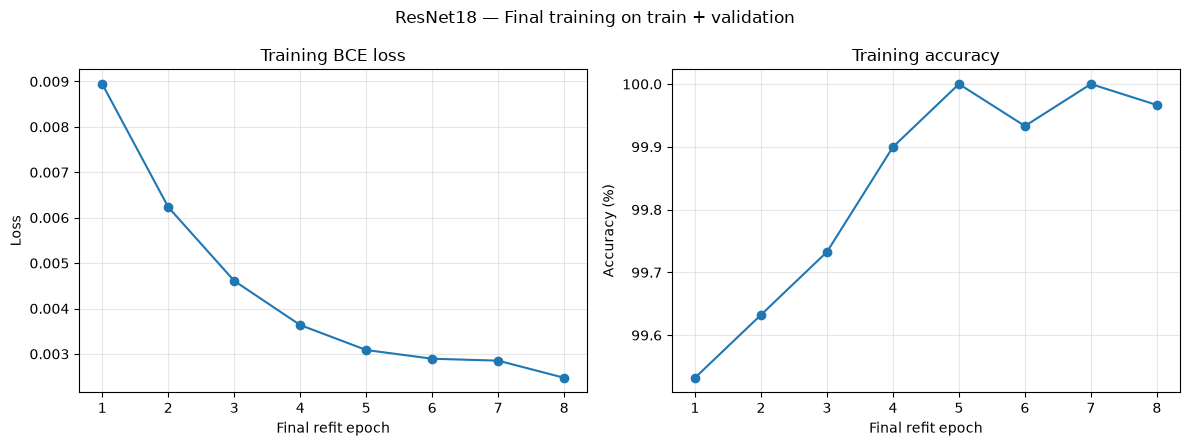

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_final_training.png
Total training time: 61.6 minutes


In [26]:
import matplotlib.pyplot as plt

history = pd.read_csv(
    FINAL_DIR / "final_training_history.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    history["epoch"], history["train_loss"],
    marker="o"
)
axes[0].set_title("Training BCE loss")
axes[0].set_ylabel("Loss")

axes[1].plot(
    history["epoch"], history["train_accuracy"] * 100,
    marker="o"
)
axes[1].set_title("Training accuracy")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Final refit epoch")
    ax.set_xticks(history["epoch"])
    ax.grid(alpha=0.3)

fig.suptitle("ResNet18 — Final training on train + validation")
fig.tight_layout()

figure_dir = PROJECT_ROOT / "outputs" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "resnet18_final_training.png"

fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print(
    "Total training time:",
    f"{history['seconds'].sum() / 60:.1f} minutes"
)